# 🧠 HUẤN LUYỆN MẠNG NƠ-RON TÍCH CHẬP (CNN) NHẬN DIỆN U NÃO VÀ GRAD-CAM
**Nhóm 9 - Học Máy 2026**

Notebook này thực hiện huấn luyện mô hình học sâu **CNN** bằng thư viện **PyTorch** để phân loại u não qua ảnh MRI, kết hợp các thuật toán tiền xử lý ảnh của **OpenCV** và giải thích mô hình bằng bản đồ nhiệt **Grad-CAM**.

C:\Users\Admin\AppData\Local\Temp\ipykernel_20024\2419670486.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=class_counts, palette='viridis')


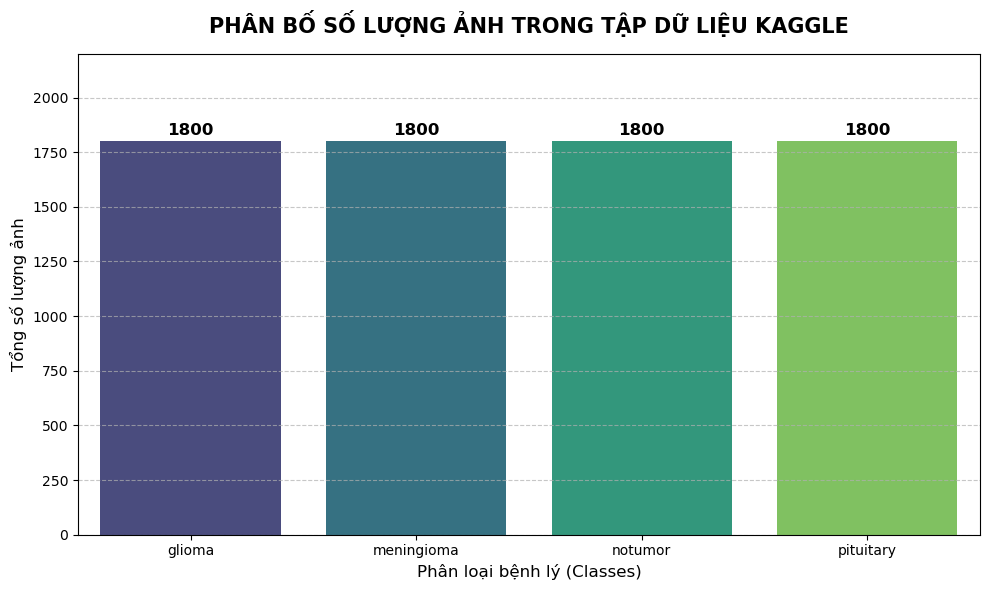

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới thư mục chứa dữ liệu Kaggle
dataset_path = 'Kaggle_Dataset'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Đếm số lượng ảnh trong từng thư mục
class_counts = []
for c in classes:
    # SỬA LẠI THÀNH Train VÀ Test CHO ĐÚNG VỚI FOLDER CỦA BẠN
    train_dir = os.path.join(dataset_path, 'Train', c)
    test_dir = os.path.join(dataset_path, 'Test', c)
    
    # Tính tổng số lượng ảnh (Train + Test)
    total_images = len(os.listdir(train_dir)) + len(os.listdir(test_dir))
    class_counts.append(total_images)

# Tiến hành vẽ đồ thị Bar Chart
plt.figure(figsize=(10, 6))
# Sử dụng bảng màu viridis cho có tính học thuật cao
sns.barplot(x=classes, y=class_counts, palette='viridis')

# Trang trí tiêu đề và các trục
plt.title('PHÂN BỐ SỐ LƯỢNG ẢNH TRONG TẬP DỮ LIỆU KAGGLE', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Phân loại bệnh lý (Classes)', fontsize=12)
plt.ylabel('Tổng số lượng ảnh', fontsize=12)

# Vòng lặp để ghi các con số đếm cụ thể lên trên đỉnh mỗi cột
for i, count in enumerate(class_counts):
    plt.text(i, count + 30, str(count), ha='center', fontsize=12, fontweight='bold', color='black')

# Đẩy trục Y lên một chút để chữ không bị sát lề
plt.ylim(0, max(class_counts) + 400) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Khai báo thư viện

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Nhập các tiện ích tự xây dựng từ utils.py
from utils import (
    BrainTumorCNN, BrainTumorCNN_V2, BrainTumorCNN_V3,
    GradCAM,
    preprocess_image_for_model,
    # setup_synthetic_dataset
)

# Thiết lập hạt giống ngẫu nhiên để tái lặp kết quả
torch.manual_seed(42)
np.random.seed(42)

### Xây dựng Class Dataset PyTorch để Load ảnh

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, base_dir, split="train"):
        # Tự động hỗ trợ cả thư mục 'Training' và 'Testing' của người dùng giải nén
        if False: # Đã tắt hardcode
            pass
        else:
            self.split_dir = os.path.join(base_dir, split)
        self.classes = ["glioma", "meningioma", "notumor", "pituitary"]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        self.image_paths = []
        self.labels = []
        self.split = split
        self.aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomRotation(15), T.RandomAffine(degrees=0, translate=(0.1, 0.1))]) if split.lower() == "train" else None
        
        for c in self.classes:
            class_path = os.path.join(self.split_dir, c)
            if not os.path.exists(class_path): 
                continue
            for filename in os.listdir(class_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_path, filename))
                    self.labels.append(self.class_to_idx[c])
                    
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Đọc ảnh gốc bằng OpenCV
        img = cv2.imread(img_path)
        
        # Thực hiện Tiền xử lý OpenCV (Cắt sọ -> Resize -> Chuẩn hóa) ở utils.py
        _, _, tensor_img = preprocess_image_for_model(img)
        
        # tensor_img ban đầu có shape (1, 3, 224, 224), ta bỏ chiều batch đi để DataLoader gom cụm
        tensor_img = tensor_img.squeeze(0)
        if self.aug:
            tensor_img = self.aug(tensor_img)
        return tensor_img, label

# Khởi tạo dataset train/test
train_dataset = BrainTumorDataset("Kaggle_Dataset", split="Train")
test_dataset = BrainTumorDataset("Kaggle_Dataset", split="Test")

# Khởi tạo DataLoader để cung cấp dữ liệu theo cụm (Batch size = 8)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test: {len(test_dataset)}")

Số lượng ảnh tập Train: 5600
Số lượng ảnh tập Test: 1600


### Khởi tạo mô hình CNN, Hàm mất mát và Thuật toán tối ưu

In [ ]:
# Khởi chạy trên CPU hoặc GPU nếu có sẵn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang chạy trên thiết bị: {device}")

model = BrainTumorCNN_V3(num_classes=4).to(device)

# Hàm lỗi Cross Entropy Loss (Dành cho phân loại đa lớp) 
criterion = nn.CrossEntropyLoss()

# Thuật toán tối ưu Adam với learning rate ban đầu là 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Thêm ReduceLROnPlateau để tự động giảm learning rate khi mô hình không cải thiện sau một số epoch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

Đang chạy trên thiết bị: cuda


### Huấn luyện mô hình (Training Loop)

In [ ]:

# ==========================================
# CẤU HÌNH HUẤN LUYỆN
# ==========================================
epochs = 50
patience = 7 # Số epoch kiên nhẫn cho Early Stopping
train_losses, train_accs = [], []
val_losses, val_accs = [] , []
best_val_loss = float('inf')
epochs_no_improve = 0
print(f"Bắt đầu huấn luyện mô hình (Dự kiến {epochs} epochs)...")
for epoch in range(epochs):
    # -------------------------
    # 1. PHA HUẤN LUYỆN (TRAINING)
    # -------------------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # -------------------------
    # 2. PHA ĐÁNH GIÁ (VALIDATION)
    # -------------------------
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, targets in test_loader: # Dùng tập test làm validation
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()
            
    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}%")
    
    # Cập nhật Scheduler dựa trên val_loss
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  => Tốc độ học hiện tại: {current_lr:.6f}")
    
    # -------------------------
    # 3. EARLY STOPPING & CHECKPOINTING
    # -------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_kaggle_v3.pth")
        print(f"  => Validation Loss giảm, đã lưu mô hình tốt nhất!")
    else:
        epochs_no_improve += 1
        print(f"  => Validation Loss không cải thiện ({epochs_no_improve}/{patience})")
        
    if epochs_no_improve >= patience:
        print(f"\n🚀 Đã kích hoạt Early Stopping tại epoch {epoch+1}!")
        break
# Xuất lịch sử huấn luyện ra file JSON
history = {
    "train_losses": train_losses, "train_accs": train_accs,
    "val_losses": val_losses, "val_accs": val_accs
}
with open("history_kaggle_v3.json", "w") as f:
    json.dump(history, f)
print("\nĐã hoàn tất quá trình huấn luyện và lưu lịch sử!")

Bắt đầu huấn luyện mô hình (Dự kiến 50 epochs)...
Epoch [1/50] | Train Loss: 1.0435 - Acc: 56.09% | Val Loss: 4.7183 - Acc: 32.56%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss giảm, đã lưu mô hình tốt nhất!
Epoch [2/50] | Train Loss: 0.8795 - Acc: 64.20% | Val Loss: 1.4348 - Acc: 51.31%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss giảm, đã lưu mô hình tốt nhất!
Epoch [3/50] | Train Loss: 0.7886 - Acc: 68.70% | Val Loss: 1.6708 - Acc: 54.44%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss không cải thiện (1/7)
Epoch [4/50] | Train Loss: 0.6694 - Acc: 74.34% | Val Loss: 2.7638 - Acc: 41.88%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss không cải thiện (2/7)
Epoch [5/50] | Train Loss: 0.6095 - Acc: 78.16% | Val Loss: 2.0629 - Acc: 57.56%
  => Tốc độ học hiện tại: 0.000300
  => Validation Loss không cải thiện (3/7)
Epoch [6/50] | Train Loss: 0.4838 - Acc: 82.38% | Val Loss: 0.9056 - Acc: 69.00%
  => Tốc độ học hiện tại: 0.000300
  => Validation Loss 

###  Đánh giá mô hình trên tập Test (Evaluation Metrics)

✅ Đã tải mô hình tốt nhất từ 'best_model_kaggle_v3.pth' để đánh giá.

=== BÁO CÁO HIỆU NĂNG MÔ HÌNH (SKLEARN) ===
              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       400
  meningioma       0.84      0.89      0.87       400
     notumor       0.87      0.97      0.92       400
   pituitary       0.94      0.98      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



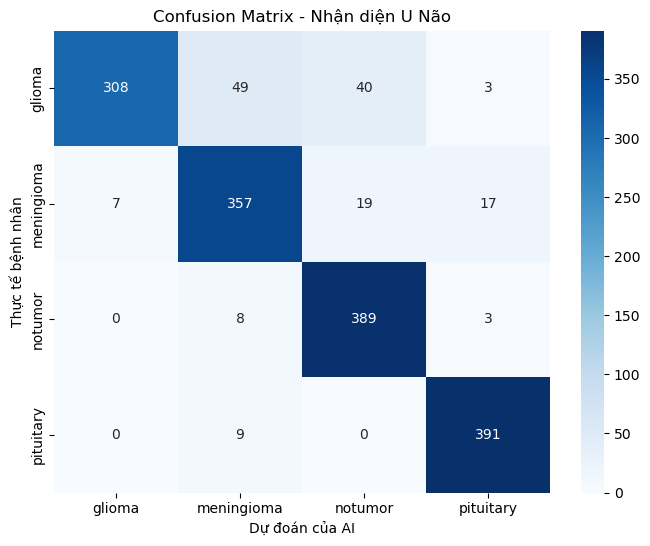

In [ ]:
# Tải lại trọng số tốt nhất (nếu có) trước khi đánh giá chi tiết
if os.path.exists("best_model_kaggle_v3.pth"):
    model.load_state_dict(torch.load("best_model_kaggle_v3.pth", map_location=device, weights_only=True))
    print("✅ Đã tải mô hình tốt nhất từ 'best_model_kaggle_v3.pth' để đánh giá.\n")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

classes = ["glioma", "meningioma", "notumor", "pituitary"]

# 1. In báo cáo các chỉ số Accuracy, Precision, Recall, F1-Score
print("=== BÁO CÁO HIỆU NĂNG MÔ HÌNH (SKLEARN) ===")
print(classification_report(all_targets, all_preds, target_names=classes))

# 2. Vẽ ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Nhận diện U Não")
plt.xlabel("Dự đoán của AI")
plt.ylabel("Thực tế bệnh nhân")
plt.show()

###  Trực quan hóa đường cong học tập (Loss và Accuracy)

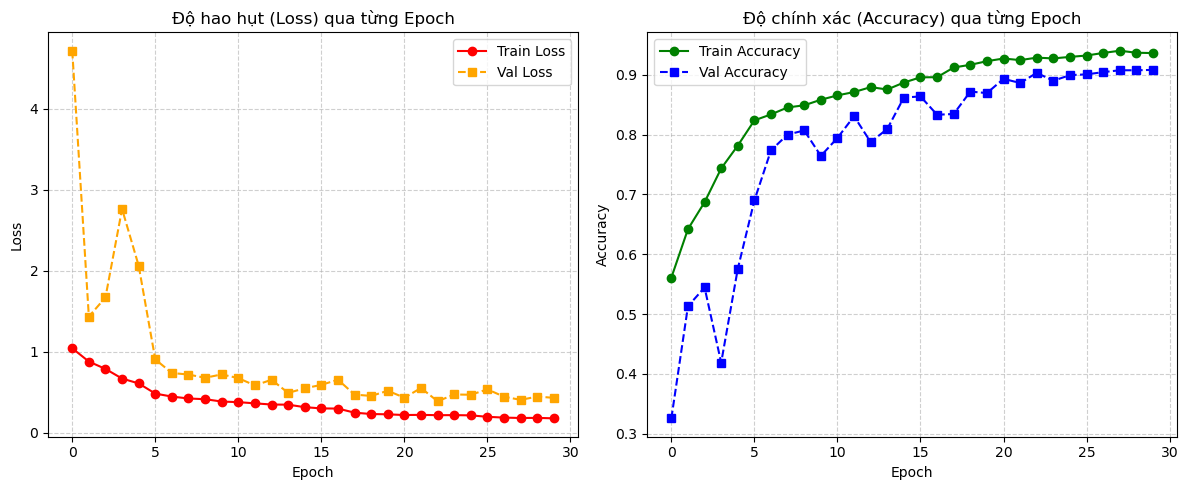

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color='red', marker='o')
plt.plot(val_losses, label="Val Loss", color='orange', marker='s', linestyle='--')
plt.title("Độ hao hụt (Loss) qua từng Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy", color='green', marker='o')
plt.plot(val_accs, label="Val Accuracy", color='blue', marker='s', linestyle='--')
plt.title("Độ chính xác (Accuracy) qua từng Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Thử nghiệm thuật toán giải thích Grad-CAM trên ảnh mẫu

In [ ]:
def explain_tumor_image(image_path, target_model, class_idx=None):
    """
    Hàm giải thích ảnh MRI bằng Grad-CAM từ đường dẫn ảnh bất kỳ.
    """
    # 1. Đọc ảnh từ đường dẫn thủ công
    orig_img = cv2.imread(image_path)
    if orig_img is None:
        print(f"❌ Lỗi: Không tìm thấy ảnh hoặc đường dẫn sai tại: {image_path}")
        return
        
    # 2. Tiền xử lý ảnh
    cropped, resized, tensor_img = preprocess_image_for_model(orig_img)
    tensor_img = tensor_img.to(device)
    classes = ["glioma", "meningioma", "notumor", "pituitary"]
    # 3. Chạy dự đoán để lấy nhãn nếu người dùng không chỉ định
    if class_idx is None:
        target_model.eval()
        with torch.no_grad():
            outputs = target_model(tensor_img)
            class_idx = torch.argmax(outputs, dim=1).item()
            confidence = torch.nn.functional.softmax(outputs, dim=1)[0][class_idx]
            print(f"🤖 AI dự đoán đây là: {classes[class_idx]} (Độ tự tin: {confidence*100:.1f}%)")
            
    # 4. Khởi tạo đối tượng Grad-CAM
    grad_cam = GradCAM(model=target_model, target_layer=target_model.features[-1].block[3])
    # 5. Sinh bản đồ nhiệt
    heatmap = grad_cam.generate_heatmap(tensor_img, class_idx=class_idx)
    # 6. Chồng bản đồ nhiệt lên ảnh gốc
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(resized, 0.6, heatmap_color, 0.4, 0)
    # 7. Hiển thị
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh MRI gốc")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Bản đồ nhiệt")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("AI khoanh vùng khối u")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

🤖 AI dự đoán đây là: meningioma (Độ tự tin: 89.9%)


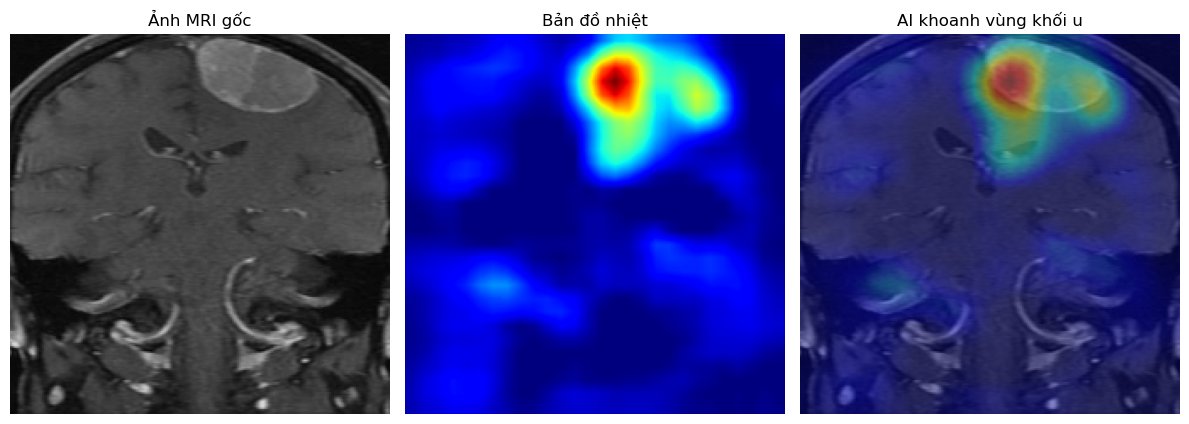

In [ ]:
# duong_dan_anh = "D:\Brain_Tumor_Project\Kaggle_Dataset\Test\glioma\Te-gl_53.jpg"
# duong_dan_anh = "D:\Brain_Tumor_Project\Kaggle_Dataset\Test\pituitary\Te-pi_37.jpg"
duong_dan_anh = r"D:\Brain_Tumor_Project\Kaggle_Dataset\Test\meningioma\Te-me_1.jpg"
explain_tumor_image(duong_dan_anh, model)

### Lưu trọng số mô hình tốt nhất

In [ ]:
model_save_path = "brain_tumor_cnn.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Đã lưu thành công trọng số mô hình tại tệp '{model_save_path}'!")

Đã lưu thành công trọng số mô hình tại tệp 'brain_tumor_cnn.pth'!
